

# **1. Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# **2. Loading the dataset**

In [ ]:
data = pd.read_csv("/content/MHRDS Dataset - Updated.csv")
data.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22.0,90.0,60.0,9.0,100.0,18.0,1.0,1.0,0.0,1.0,80.0,High
1,22.0,110.0,70.0,7.1,98.0,20.4,0.0,0.0,0.0,0.0,74.0,Low
2,27.0,110.0,70.0,7.5,98.0,23.0,1.0,0.0,0.0,0.0,72.0,Low
3,20.0,100.0,70.0,7.2,98.0,21.2,0.0,0.0,0.0,0.0,74.0,Low
4,20.0,90.0,60.0,7.5,98.0,19.7,0.0,0.0,0.0,0.0,74.0,Low


# **3. Preparing the data**

In [ ]:
# Dataset Information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1207 non-null   float64
 1   Systolic BP             1202 non-null   float64
 2   Diastolic               1203 non-null   float64
 3   BS                      1205 non-null   float64
 4   Body Temp               1207 non-null   float64
 5   BMI                     1189 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   float64
 9   Mental Health           1205 non-null   float64
 10  Heart Rate              1205 non-null   float64
 11  Risk Level              1187 non-null   object 
dtypes: float64(11), object(1)
memory usage: 113.4+ KB


In [ ]:
# Handling Duplicate Values
print("Dataset before removing duplicates:")
print(data.shape)

data = data.drop_duplicates()

print("\nDataset after removing duplicates:")
print(data.shape)

Dataset before removing duplicates:
(1208, 12)

Dataset after removing duplicates:
(1190, 12)


In [ ]:
# Handling Null/NA/Missing values
data.isnull().sum()

,0
Age,1
Systolic BP,6
Diastolic,5
BS,3
Body Temp,1
BMI,19
Previous Complications,5
Preexisting Diabetes,5
Gestational Diabetes,3
Mental Health,3


In [ ]:
# Finding mean and mode values
print(data["Age"].mean())
print(data["Systolic BP"].mean())
print(data["Diastolic"].mean())
print(data["BS"].mean())
print(data["Body Temp"].mean())
print(data["BMI"].mean())
print(data["Heart Rate"].mean())

print(data["Previous Complications"].mode())
print(data["Preexisting Diabetes"].mode())
print(data["Gestational Diabetes"].mode())
print(data["Mental Health"].mode())
print(data["Risk Level"].mode())

27.527905803195964
116.72173986486487
77.13964556962026
7.504069081718618
98.32000841042893
23.31793339026473
75.79869418702611
0    0.0
Name: Previous Complications, dtype: float64
0    0.0
Name: Preexisting Diabetes, dtype: float64
0    0.0
Name: Gestational Diabetes, dtype: float64
0    0.0
Name: Mental Health, dtype: float64
0    Low
Name: Risk Level, dtype: object


In [ ]:
# Replacing numerical columns with its mean values
data[["Age", "Systolic BP", "Diastolic", "BS", "BMI", "Heart Rate", "Body Temp"]] = data[["Age", "Systolic BP", "Diastolic", "BS", "BMI", "Heart Rate", "Body Temp"]].fillna(
                                                                data[["Age", "Systolic BP", "Diastolic", "BS", "BMI", "Heart Rate", "Body Temp"]].mean())

# Replacing categorical columns with its mode values
data[["Previous Complications", "Preexisting Diabetes", "Gestational Diabetes", "Mental Health"]] = data[["Previous Complications", "Preexisting Diabetes", "Gestational Diabetes", "Mental Health"]].fillna(
                                                           data[["Previous Complications", "Preexisting Diabetes", "Gestational Diabetes", "Mental Health"]].mode().iloc[0])

data["Risk Level"] = data["Risk Level"].fillna(data["Risk Level"].mode().iloc[0])

# Rechecking the null values
data[["Age", "Systolic BP", "Diastolic", "BS", "BMI", "Heart Rate", "Previous Complications", "Preexisting Diabetes", "Risk Level", "Body Temp"]].isnull().sum()

,0
Age,0
Systolic BP,0
Diastolic,0
BS,0
BMI,0
Heart Rate,0
Previous Complications,0
Preexisting Diabetes,0
Risk Level,0
Body Temp,0


In [ ]:
# Label Encoding
data["Risk Level"].unique()

data = data.replace({"High":1, "Low":0})
data.head()

/tmp/ipython-input-3180733820.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({"High":1, "Low":0})


,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22.0,90.0,60.0,9.0,100.0,18.0,1.0,1.0,0.0,1.0,80.0,1
1,22.0,110.0,70.0,7.1,98.0,20.4,0.0,0.0,0.0,0.0,74.0,0
2,27.0,110.0,70.0,7.5,98.0,23.0,1.0,0.0,0.0,0.0,72.0,0
3,20.0,100.0,70.0,7.2,98.0,21.2,0.0,0.0,0.0,0.0,74.0,0
4,20.0,90.0,60.0,7.5,98.0,19.7,0.0,0.0,0.0,0.0,74.0,0


In [ ]:
data[["Age", "Systolic BP", "Diastolic", "Heart Rate", "Previous Complications", "Preexisting Diabetes", "Gestational Diabetes", "Mental Health"]] = data[["Age", "Systolic BP", "Diastolic", "Heart Rate", "Previous Complications", "Preexisting Diabetes", "Gestational Diabetes", "Mental Health"]].astype(int)
print(data.dtypes)

Age                         int64
Systolic BP                 int64
Diastolic                   int64
BS                        float64
Body Temp                 float64
BMI                       float64
Previous Complications      int64
Preexisting Diabetes        int64
Gestational Diabetes        int64
Mental Health               int64
Heart Rate                  int64
Risk Level                  int64
dtype: object


In [ ]:
# Statistical Summary of Dataset
data.describe()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,27.526891,116.716807,77.138655,7.504069,98.320008,23.317933,0.176471,0.290756,0.119328,0.338655,75.795798,0.397479
std,9.203641,18.968425,14.458552,3.065937,3.025675,3.901213,0.381380,0.454302,0.324310,0.473451,7.506284,0.489582
min,9.000000,18.000000,14.000000,3.000000,1.090000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000
25%,21.000000,100.000000,65.000000,6.000000,98.000000,21.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000
50%,25.000000,120.000000,80.000000,6.900000,98.000000,23.000000,0.000000,0.000000,0.000000,0.000000,76.000000,0.000000
75%,32.000000,130.000000,90.000000,7.975000,98.000000,25.000000,0.000000,1.000000,0.000000,1.000000,80.000000,1.000000
max,65.000000,200.000000,140.000000,19.000000,103.000000,37.000000,1.000000,1.000000,1.000000,1.000000,92.000000,1.000000


In [ ]:
data.columns

Index(['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI',
       'Previous Complications', 'Preexisting Diabetes',
       'Gestational Diabetes', 'Mental Health', 'Heart Rate', 'Risk Level'],
      dtype='object')

In [ ]:
data.to_excel('Dataset.xlsx', index=False)

# **4. Exploratory Data Analysis**

In [ ]:
import os

# Ensure plots folder exists
os.makedirs("plots", exist_ok=True)

# Set plotting style
sns.set(style="whitegrid", palette="Set2")

In [ ]:
# Univariate analysis
# Continuous variables
continuous_features = ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate']

# 1. Histogram for Continuous Variables
for col in continuous_features:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True, color='#4DB6AC', edgecolor='white')
    #sns.histplot(data[col], kde=True, color='teal', edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.grid(False)
    plt.savefig(f"plots/hist_{col}.png")
    plt.close()

In [ ]:
# Categorical variables
categorical_cols = ['Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Risk Level']
for i, col in enumerate(categorical_cols):
    plt.figure(figsize=(6,4))
    order = data[col].value_counts().index
    sns.countplot(x=col, data=data, order=order, color="#4DB6AC", edgecolor="white")
    #sns.boxplot(x='Risk Level', y=col, data=data, palette=['#4DB6AC','#E57373'])
    plt.title(f"Count of {col}")
    plt.tight_layout()
    plt.grid(False)
    plt.savefig(f"plots/box_{col}.png")
    plt.close()

In [ ]:
# Bivariate Analysis
# 1. Categorical vs Target
bivariate_categorical = ['Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health']

for col in bivariate_categorical:
    plt.figure(figsize=(5,4))
    #sns.countplot(x=col, hue='Risk Level', data=data, palette='pastel')
    sns.countplot(x=col, hue='Risk Level', data=data, palette=['#4DB6AC','#E57373'])
    plt.title(f"{col} vs Risk Level")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title='Risk Level')
    plt.tight_layout()
    plt.grid(False)
    plt.savefig(f"plots/bivar_cat_{col}.png")
    plt.close()

In [ ]:
# 2. Numerical vs Target (Boxplot + Violin Plot)
numerical_features = ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate']

for col in numerical_features:
    # Boxplot
    plt.figure(figsize=(5,4))
    #sns.boxplot(x='Risk Level', y=col, data=data, palette='pastel')
    sns.boxplot(x='Risk Level', y=col, data=data, palette=['#4DB6AC','#E57373'])
    plt.title(f"Boxplot of {col} by Risk Level")
    plt.tight_layout()
    plt.grid(False)
    plt.savefig(f"plots/boxplot_{col}_vs_risk.png")
    plt.close()

    # Violin Plot
    plt.figure(figsize=(5,4))
    #sns.violinplot(x='Risk Level', y=col, data=data, palette='muted', inner='quartile')
    sns.violinplot(x='Risk Level', y=col, data=data, palette=['#4DB6AC','#E57373'], inner='quartile')
    plt.title(f"Violin Plot of {col} by Risk Level")
    plt.tight_layout()
    plt.grid(False)
    plt.savefig(f"plots/violin_{col}_vs_risk.png")
    plt.close()

/tmp/ipython-input-3807706464.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk Level', y=col, data=data, palette=['#4DB6AC','#E57373'])
/tmp/ipython-input-3807706464.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Risk Level', y=col, data=data, palette=['#4DB6AC','#E57373'], inner='quartile')
/tmp/ipython-input-3807706464.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk Level', y=col, data=data, palette=['#4DB6AC','#E57373'])
/tmp/ipython-input-3807706464.py:18: FutureWarning: 

Passing `palette` without assi

# **Exploratory Works**

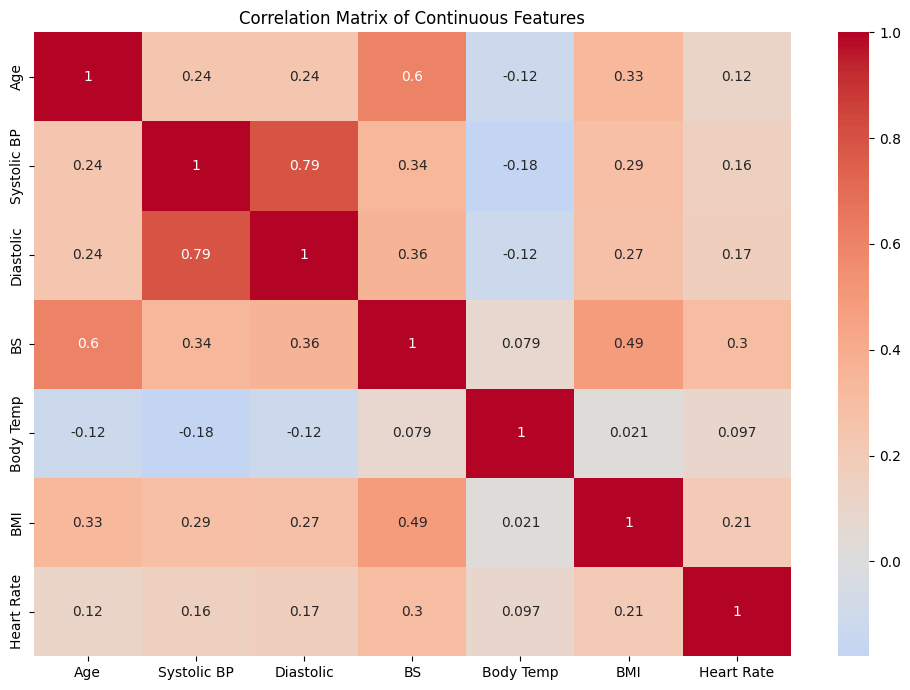

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,7))
corr = data[continuous_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Continuous Features')
plt.tight_layout()
plt.show()

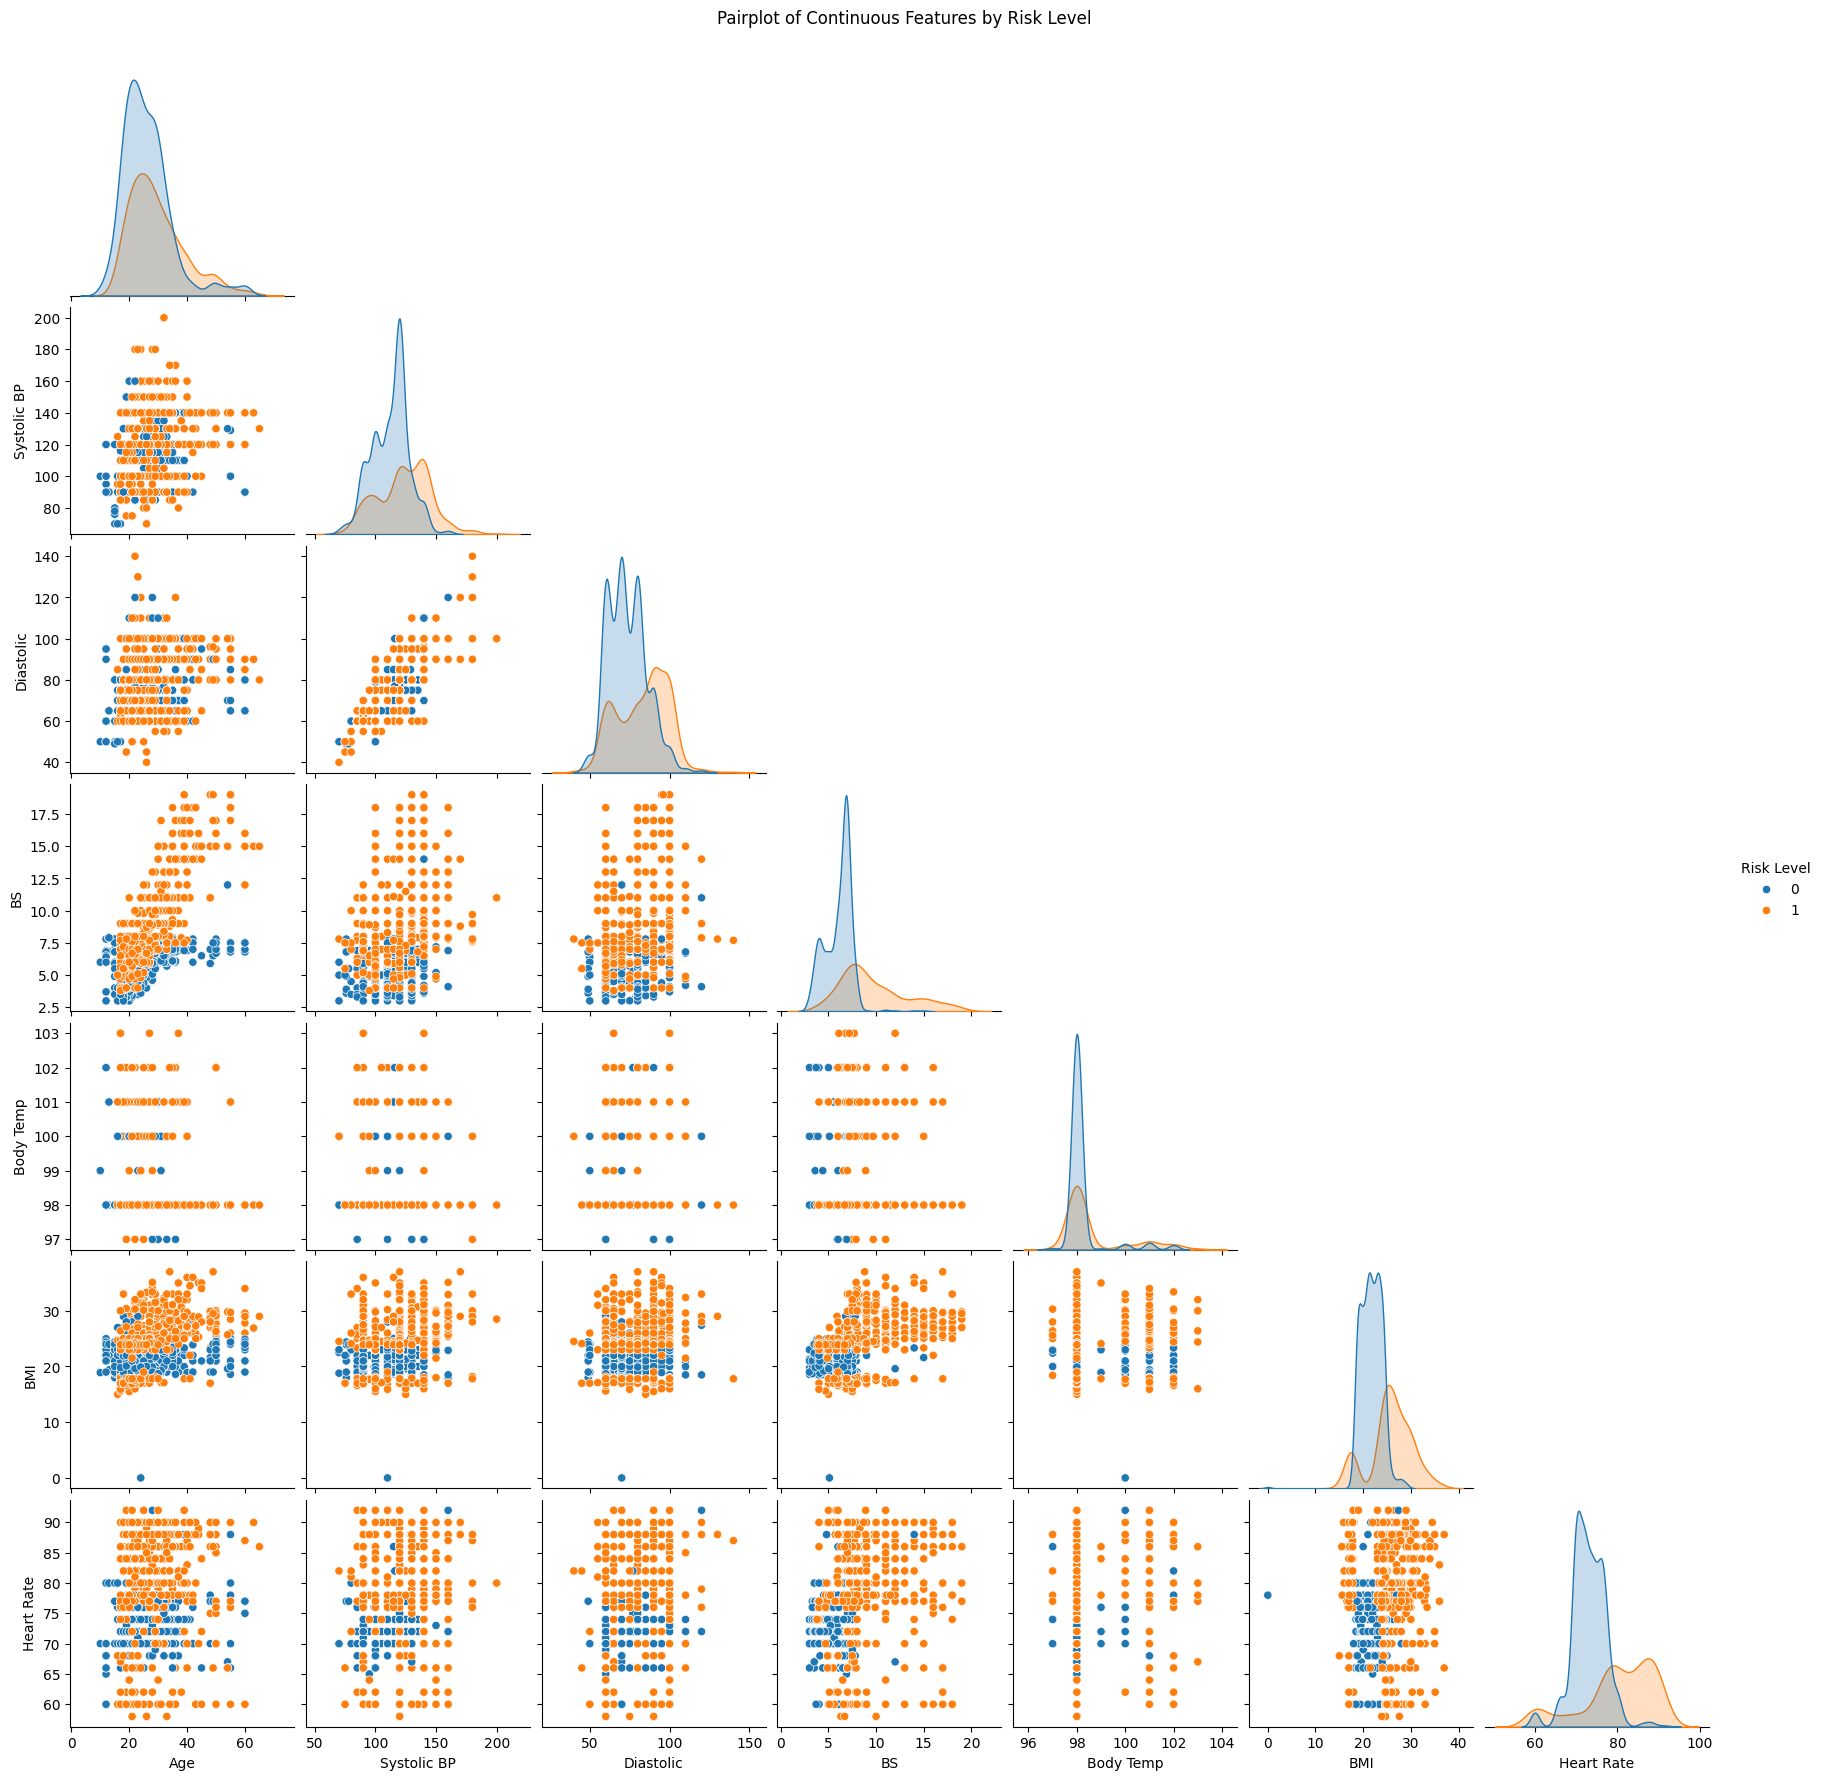

In [ ]:
# Pairplot colored by Risk Level
sns.pairplot(data, vars=continuous_cols, hue="Risk Level", corner=True, diag_kind='kde')
plt.suptitle('Pairplot of Continuous Features by Risk Level', y=1.02)
plt.show()

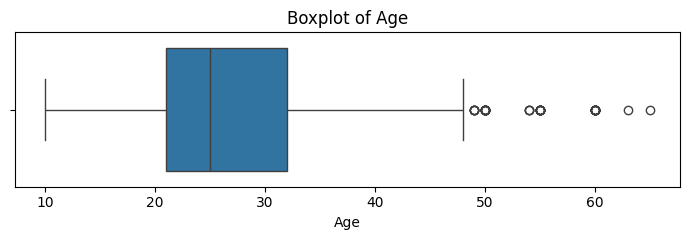

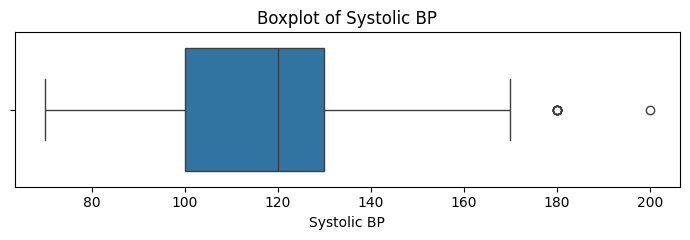

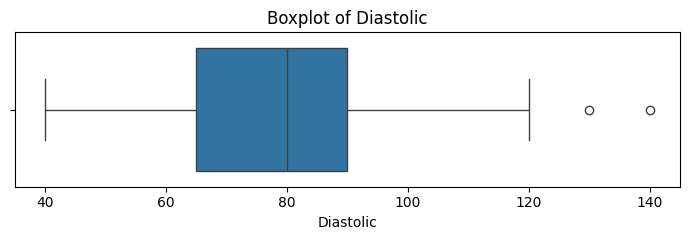

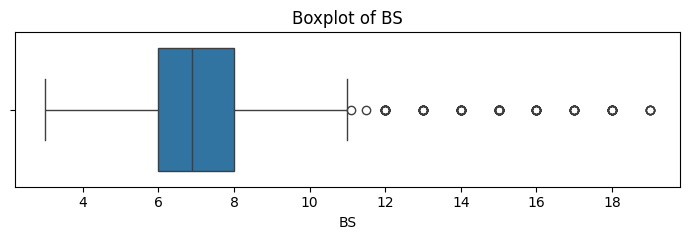

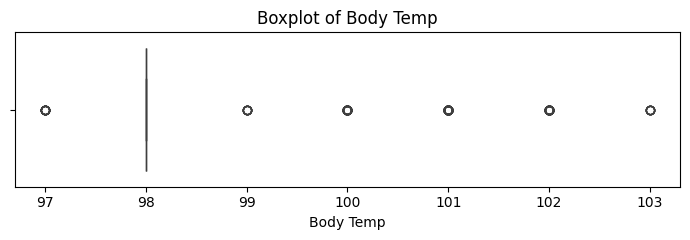

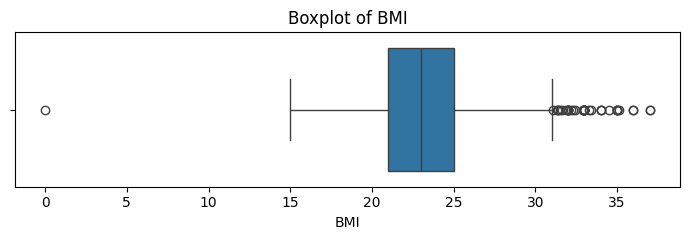

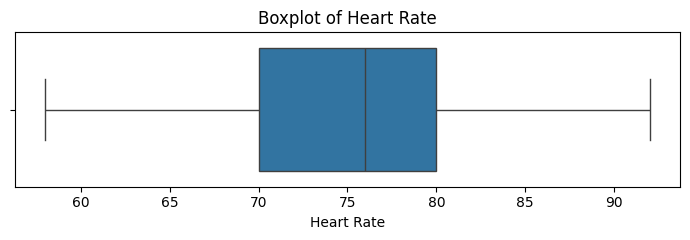

In [ ]:
# Outlier detection (boxplots)
for i, col in enumerate(continuous_cols):
    plt.figure(figsize=(7,2.5))
    sns.boxplot(data=data, x=col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

# **5. Predictive Modelling**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
X = data.drop('Risk Level', axis=1)
y = data['Risk Level']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **5.1. Logistic Regression**

In [ ]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       148
           1       0.94      0.98      0.96        90

    accuracy                           0.97       238
   macro avg       0.96      0.97      0.96       238
weighted avg       0.97      0.97      0.97       238



### **5.2. Random Forest**

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Random Forest:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98       148
           1       0.94      1.00      0.97        90

    accuracy                           0.97       238
   macro avg       0.97      0.98      0.97       238
weighted avg       0.98      0.97      0.97       238



### **5.3. SVM**

In [ ]:
# SVM classifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("SVM Classification Report:")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8487394957983193
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89       148
           1       0.91      0.67      0.77        90

    accuracy                           0.85       238
   macro avg       0.87      0.81      0.83       238
weighted avg       0.86      0.85      0.84       238



### **5.4. Decision Trees**

In [ ]:
# Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9621848739495799
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       148
           1       0.94      0.97      0.95        90

    accuracy                           0.96       238
   macro avg       0.96      0.96      0.96       238
weighted avg       0.96      0.96      0.96       238



### **5.5 Confusion Matrix**

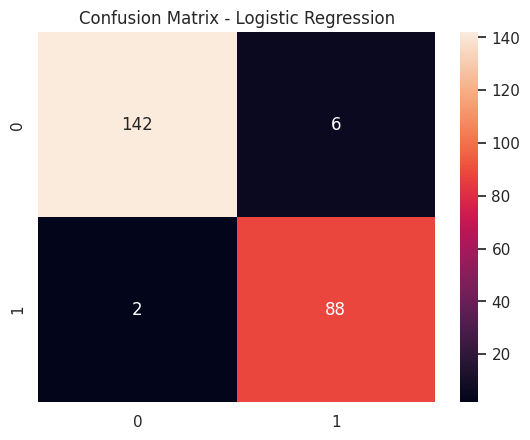

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

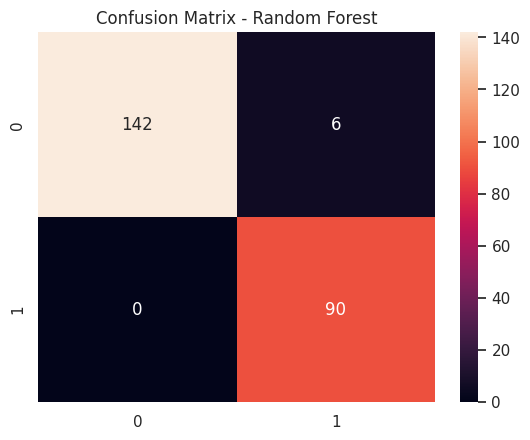

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

238 238


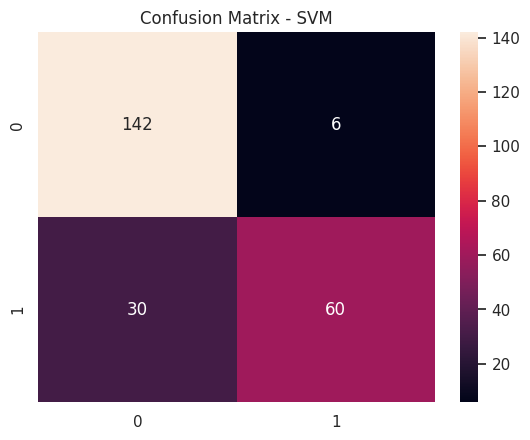

In [ ]:
print(len(y_test), len(svm_pred))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt="d")
plt.title("Confusion Matrix - SVM")
plt.show()

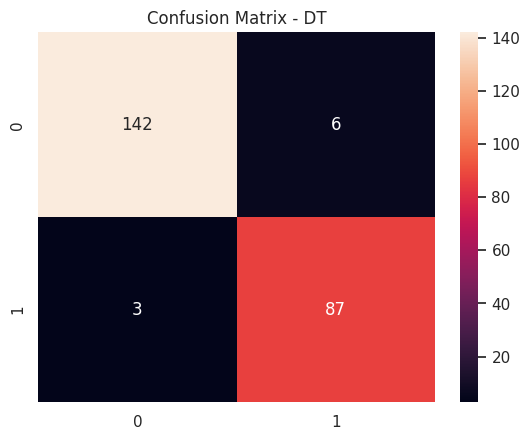

In [ ]:
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt="d")
plt.title("Confusion Matrix - DT")
plt.show()

# **6. Model Dumping**

In [ ]:
import joblib
joblib.dump(rf, "mendeley_pregnancy_model.pkl")

['mendeley_pregnancy_model.pkl']

# **7. GUI - Tkinter**

In [ ]:
import tkinter as tk
from tkinter import ttk
import joblib
import numpy as np

# Load the trained model
MODEL_PATH = "mendeley_pregnancy_model.pkl"
model = joblib.load(MODEL_PATH)

# Fields and types
fields = [
    ("Age", "entry"),
    ("Systolic BP", "entry"),
    ("Diastolic", "entry"),
    ("BMI", "entry"),
    ("Previous Complications", "dropdown"),
    ("Preexisting Diabetes", "dropdown"),
    ("Gestational Diabetes", "dropdown"),
    ("Mental Health", "dropdown"),
    ("Heart Rate", "entry")
]

# Setup window
root = tk.Tk()
root.title("Pregnancy Risk Predictor")
root.geometry("500x650")
root.configure(bg="#f9f9f9")

# Style
style = ttk.Style()
style.configure("TLabel", font=("Segoe UI", 11), background="#f9f9f9")
style.configure("TEntry", font=("Segoe UI", 11))
style.configure("TCombobox", font=("Segoe UI", 11))
style.configure("TButton", font=("Segoe UI", 12, "bold"))

# Header
title_label = ttk.Label(root, text="Pregnancy Risk Predictor", font=("Segoe UI", 18, "bold"))
title_label.pack(pady=20)

# Frame for input fields
form_frame = tk.Frame(root, bg="#f9f9f9")
form_frame.pack()

inputs = {}

# Layout input fields using grid (label left, entry right)
for idx, (label_text, field_type) in enumerate(fields):
    label = ttk.Label(form_frame, text=label_text)
    label.grid(row=idx, column=0, padx=10, pady=8, sticky=tk.W)

    if field_type == "entry":
        entry = ttk.Entry(form_frame, width=25)
        entry.grid(row=idx, column=1, padx=10, pady=8)
        inputs[label_text] = entry
    elif field_type == "dropdown":
        combo = ttk.Combobox(form_frame, values=["0 - No", "1 - Yes"], width=23, state="readonly")
        combo.current(0)
        combo.grid(row=idx, column=1, padx=10, pady=8)
        inputs[label_text] = combo

# Result display label (initially empty)
result_label = ttk.Label(root, text="", font=("Segoe UI", 14), foreground="#333")
result_label.pack(pady=20)

# Predict function
def predict():
    try:
        features = []
        for label_text, field_type in fields:
            val = inputs[label_text].get()
            if field_type == "entry":
                features.append(float(val))
            else:
                features.append(int(val.split(" - ")[0]))

        features_np = np.array([features])
        prediction = model.predict(features_np)[0]
        result = "⚠️ High Risk" if prediction == 1 else "✅ Low Risk"

        result_label.config(text=f"Predicted Risk Level: {result}")
    except ValueError:
        result_label.config(text="❌ Invalid input. Please enter numbers properly.")

# Predict Button
predict_btn = ttk.Button(root, text="Predict Risk Level", command=predict)
predict_btn.pack(pady=10)

# Run App
root.mainloop()

TclError: no display name and no $DISPLAY environment variable